# (A) Delta LWP vs. PD LWP, (B) ERFaci vs. scaled delta LWP


In [1]:
import pickle

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

import tol_colors as tc
import multi_ppe_constraint_rev as mpc

from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


In [2]:
main_path = "/glade/u/home/jnug/work/multi_PPE_data/"
file_path = main_path + "annual_means/"
save_dir = "/glade/work/jnug/codes/e3sm-ppe-aci/analysis/notebooks/multi_PPE_adj/revisions/figures/"
pickle_path = main_path + "pickle_jar/"


### Get data

#### PPE & CMIP6

In [3]:
ds_e3sm = xr.open_dataset(file_path + "E3SMv3_data_annual_means.nc")
ds_ga71 = xr.open_dataset(file_path + "GA7.1_data_annual_means.nc")
ds_cam6 = xr.open_dataset(file_path + "CAM6_data_annual_means.nc") 
ds_eham = xr.open_dataset(file_path + "ECHAM6-HAM_data_annual_means.nc") 

# add da/dlwp to PPE members
with open(pickle_path + "PPE_dadlwp_dict.pickle", "rb") as handle:
    ppe_dadlwp_dict = pickle.load(handle)
ds_e3sm = ds_e3sm.assign({"dadlwp": ppe_dadlwp_dict["E3SMv3"].rename({"LWP_pd_masked", "dadlwp"})})
ds_ga71 = ds_ga71.assign({"dadlwp": ppe_dadlwp_dict["GA7.1"].rename({"LWP_pd_masked", "dadlwp"})})
ds_cam6 = ds_cam6.assign({"dadlwp": ppe_dadlwp_dict["CAM6"].rename({"LWP_pd_masked", "dadlwp"})})
ds_eham = ds_eham.assign({"dadlwp": ppe_dadlwp_dict["ECHAM6-HAM"].rename({"LWP_pd_masked", "dadlwp"})})

# make a PPE dataset dictionary
ds_dict = {"E3SMv3": ds_e3sm, "GA7.1": ds_ga71, "CAM6": ds_cam6, "ECHAM6-HAM": ds_eham}
    

In [4]:
# CMIP6 
with open(file_path + "CMIP6_all_data_annual_means.pickle", "rb") as handle:
    cmip6_dict = pickle.load(handle)
    
# add da/dlwp to CMIP6 dict
with open(pickle_path + "CMIP6_all_dadlwp_dict.pickle", "rb") as handle:
    cmip6_dadlwp_dict = pickle.load(handle)

for key, item in cmip6_dict.items():
    dadlwp = cmip6_dadlwp_dict[key]
    item["dadlwp"] = dadlwp
    cmip6_dict[key] = item
    

In [5]:
len(list(cmip6_dict.keys()))

15

In [6]:
list(cmip6_dict.keys())

['MRI-ESM2-0',
 'GISS-E2-1-G',
 'MPI-ESM-1-2-HAM',
 'BCC-ESM1',
 'NorESM2-LM',
 'NorESM2-MM',
 'CanESM5',
 'CESM2',
 'CNRM-CM6-1',
 'CNRM-ESM2-1',
 'GFDL-CM4',
 'HadGEM3-GC31-LL',
 'IPSL-CM6A-LR',
 'MIROC6',
 'UKESM1-0-LL']

#### MAC-LWP obs 
Values from Ci's paper - Song et al. 2024, GRL


In [7]:
pd_lwp_mac_min = 65
pd_lwp_mac_max = 80

pd_lnLWP_mac = [np.log(pd_lwp_mac_min), np.log(pd_lwp_mac_max)]
pd_LWP_mac = [pd_lwp_mac_min, pd_lwp_mac_max]


### Get model data ready for plotting

In [8]:
cmip6_keys = list(cmip6_dict.keys())

ppe_dict = {
    "GA7.1": {"LWP": ds_ga71["LWP_pd_masked"], "dLWP": ds_ga71["delta_LWP"],
             "ERFaci": ds_ga71["ERFaci"], "dLWP_dadlwp": ds_ga71["delta_LWP"]/1000.*ds_ga71["dadlwp"],
             "delta_Nd": ds_ga71["delta_Nd"]},
    
    "E3SMv3": {"LWP": ds_e3sm["LWP_pd_masked"], "dLWP": ds_e3sm["delta_LWP"],
              "ERFaci": ds_e3sm["ERFaci"], "dLWP_dadlwp": ds_e3sm["delta_LWP"]/1000.*ds_e3sm["dadlwp"],
             "delta_Nd": ds_e3sm["delta_Nd"]},
    
    "CAM6": {"LWP": ds_cam6["LWP_pd_masked"], "dLWP": ds_cam6["delta_LWP"],
            "ERFaci": ds_cam6["ERFaci"], "dLWP_dadlwp": ds_cam6["delta_LWP"]/1000.*ds_cam6["dadlwp"],
             "delta_Nd": ds_cam6["delta_Nd"]},
    
    "ECHAM6-HAM": {"LWP": ds_eham["LWP_pd_masked"], "dLWP": ds_eham["delta_LWP"],
                  "ERFaci": ds_eham["ERFaci"], "dLWP_dadlwp": ds_eham["delta_LWP"]/1000.*ds_eham["dadlwp"],
             "delta_Nd": ds_eham["delta_Nd"]},
    
    "CMIP6": {"LWP": dict(zip(cmip6_keys, [cmip6_dict[key]["LWP_pd_masked"] for key in cmip6_keys])),
             "dLWP": dict(zip(cmip6_keys, [cmip6_dict[key]["delta_LWP"] for key in cmip6_keys])),
             "ERFaci": dict(zip(cmip6_keys, [cmip6_dict[key]["ERFaci"] for key in cmip6_keys])),
             "dLWP_dadlwp": dict(zip(cmip6_keys, [cmip6_dict[key]["delta_LWP"]/1000.*cmip6_dict[key]["dadlwp"] for key in cmip6_keys]))},
}


In [9]:
# for Fig S2
ppe_dict_log = {
    "GA7.1": {"LWP": np.log(ds_ga71["LWP_pd_masked"]), 
               "dLWP": (np.log(ds_ga71["LWP_pd"]) - np.log(ds_ga71["LWP_pi"]))}, 
    "E3SMv3": {"LWP": np.log(ds_e3sm["LWP_pd_masked"]), 
               "dLWP": (np.log(ds_e3sm["LWP_pd"]) - np.log(ds_e3sm["LWP_pi"]))},
    "CAM6": {"LWP": np.log(ds_cam6["LWP_pd_masked"]), 
               "dLWP": (np.log(ds_cam6["LWP_pd"]) - np.log(ds_cam6["LWP_pi"]))},
    "ECHAM6-HAM": {"LWP": np.log(ds_eham["LWP_pd_masked"]), 
               "dLWP": (np.log(ds_eham["LWP_pd"]) - np.log(ds_eham["LWP_pi"]))},
    "CMIP6": {"LWP": dict(zip(cmip6_keys, [np.log(cmip6_dict[key]["LWP_pd_masked"]) for key in cmip6_keys])),
             "dLWP": dict(zip(cmip6_keys, [cmip6_dict[key]["delta_lnLWP"] for key in cmip6_keys]))},
}

In [10]:
# add fit lines, dNd and da/dlwp ensemble members, and ERFaci ranges for PPE members
# here, use the constrained fit lines (not the prior)

for ppe in list(ds_dict.keys()):
    # fit lines
    ppe_dict[ppe]["fit_coeffs"] = mpc.read_fit_line(ppe, "ERFaci_dLWPxdadlwp_constr_Ndpipd", degree=1, out_path=pickle_path)

    # constraints - 5% tolerance
    with open(pickle_path + f"{ppe}_constrained_members_dict_error_tol_0.05.pickle", "rb") as handle:
        err05_dict = pickle.load(handle)
    dadlwp_meet = err05_dict["dadlwp"]["match"]
    lwp_meet = err05_dict["LWP_pd"]["match"]
    dnd_meet = err05_dict["delta_Nd_pipd"]["match"]
    good = [x for x in dnd_meet if (x in dadlwp_meet and x in lwp_meet)]
   
    ppe_dict[ppe]["good_ensn"] = good
    ppe_dict_log[ppe]["good_ensn"] = good


In [11]:
# quick - get coeffs for ERFaci vs. dLWP, constrained (no scaling)
for ppe, ds in ds_dict.items():
    good = ppe_dict[ppe]["good_ensn"]
    ds_good = ds.sel(member=good)
    
    x = ds_good["delta_LWP"]
    y = ds_good["ERFaci"]

    ppe_dict[ppe]["noscale_coeffs"] = mpc.get_fit_line(ppe, x, y, degree=1, print_r2=True)



E3SMv3: r2 = 0.635
GA7.1: r2 = 0.863
CAM6: r2 = 0.411
ECHAM6-HAM: r2 = 0.712


### PLOT

In [12]:
# this is tol_cset("muted") with 6 additional colors

tol_muted_exp = {
    'rose': '#CC6677',
    'indigo': '#332288',
    'sand': '#DDCC77',
    'green': '#117733',
    'cyan': '#88CCEE',
    'wine': '#882255',
    'teal': '#44AA99',
    'olive': '#999933',
    'purple': '#AA4499',
    # 'pale_grey': '#DDDDDD', # skip this one
    'sky_blue': '#6699CC', # added
    'burnt_orange': '#CC5500', # added
    'forest_brown': '#664422', # added
    'slate_blue': '#5A5AAE', # added
    'charcoal': '#777777', # added
    'gold': '#C7922E' # added
}

cmip6_colors_new = list(tol_muted_exp.values())


In [13]:
def plot_comb_fig(ppe_dict, xlim=None, ylim=None, xalim=None, yalim=None, xblim=None, yblim=None,
                           figsize=(13, 6), fsize=14, tsize=16, labsize=12, obs_range=None,
                           alpha_ppe=0.5, s_ppe=20, s_cmip6=75, lw_wcrp=2, col_wcrp="#66CCEE",
                           alpha_wcrp=0.075, capsize=7, error_width=2.5,  save=False, extra="",
                           cmip6_colors=None, cmip6_markers=None, cmip6_plot_order=None):
    """ Plot (A) PD LWP vs delta LWP and (B) ERFaci vs. ∆LWP*da/dlwp
    """
    if cmip6_colors is None:
        cmip6_colors = cmip6_colors_new # see above
    if cmip6_markers is None:
        cmip6_markers = ['v', 'P', '^', 'X', '>', 'h', '*', 's', 'H',
                         'o', 'D', 'p', '<', 'd', '8']
    if cmip6_plot_order is None:
        cmip6_plot_order = ["UKESM1-0-LL", "MIROC6", "IPSL-CM6A-LR", "CNRM-CM6-1", 
                            "CESM2", "GFDL-CM4", "HadGEM3-GC31-LL", "CanESM5", "BCC-ESM1",
                            "MRI-ESM2-0", "GISS-E2-1-G", "MPI-ESM-1-2-HAM", "CNRM-ESM2-1", 
                            "NorESM2-LM", "NorESM2-MM"]


    # hardcode PPE plot colors
    col_dict = {"GA7.1": "#DDAA33", "E3SMv3": "#004488", "CAM6": "#BB5566", "ECHAM6-HAM": "#228833"} # from tol-colors "high contrast", plus green
    est_col = "#997700" # for the multi-PPE best estimate

    # plot limits
    if xblim is None:
        xblim = (-0.005, 0.0175)
    if yblim is None:
        yblim = (-4, 2.2)
    if xalim is None:
        xalim=(-10, 350)
    if yalim is None:
        yalim=(-2.5, 9.5)
            
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(2, 2, height_ratios=[3, 1])
    plt.subplots_adjust(wspace=0.25, hspace=0.3)
    
    # plotting axes
    axa = plt.subplot(gs[0, 0])
    axb = plt.subplot(gs[0, 1])

    # axis for the legend
    ax_leg = plt.subplot(gs[1, :])
    ax_leg.axis("off")
    
    
    # --- set up axes & zero line ---
    for ax in [axa, axb]:
        ax.axhline(0, color="gray", linestyle="-")
        ax.tick_params(axis="both", labelsize=labsize)

    axa.set_ylabel(r"$\Delta$LWP [g/m$^2$]", fontsize=fsize)
    axa.set_xlabel("Masked PD LWP [g/m$^2$]", fontsize=fsize)
    axa.set_ylim(yalim)
    # axa.set_xlim(xalim)

    axb.axvline(0, color="gray", linestyle="-")
    axb.set_xlabel(r"$\Delta$LWP $\cdot$ $\frac{\partial \alpha}{\partial \text{LWP}}$ [fraction]", fontsize=fsize)
    axb.set_ylabel("ERF_ACI [W/m$^2$]", fontsize=fsize)
    axb.set_ylim(yblim)
    # axb.set_xlim(xblim)



    
    # --- (A) dLWP vs. PD LWP: scatter PPE output/CMIP6 ---
    if obs_range is not None:
        axa.axvspan(obs_range[0], obs_range[1], color="gray", alpha=0.25, label="MAC-LWP (obs)",
                  zorder=0)
                
    for ppe in list(ppe_dict.keys()):
        if ppe == "CMIP6":
            for i, model in enumerate(cmip6_plot_order):
                axa.scatter(ppe_dict["CMIP6"]["LWP"][model], ppe_dict["CMIP6"]["dLWP"][model], s=s_cmip6, label=model, alpha=1,
                           color=cmip6_colors[i], marker=cmip6_markers[i], edgecolor="k", linewidth=1.5, zorder=100)
        else:
            for ensn in ppe_dict[ppe]["LWP"].member:
                if ensn in ppe_dict[ppe]["good_ensn"]:
                    marker = "o"
                    edgecolor="k"
                    lw = 1
                    alph = alpha_ppe
                    s = s_ppe + 10
                else:
                    marker = "x"
                    edgecolor = None
                    lw = None
                    if ppe == "ECHAM6-HAM": # smaller alpha for this one bc they're on top of each other
                        alph = 0.2
                    else:
                        alph = 0.35
                    s = s_ppe
                axa.scatter(ppe_dict[ppe]["LWP"].sel(member=ensn), ppe_dict[ppe]["dLWP"].sel(member=ensn), alpha=alph,
                           s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                          edgecolor=edgecolor, linewidth=lw)

    
    # --- (B) ERFaci vs. scaled dLWP: scatter PPE output/CMIP6 & lin fit lines ---
    # PPEs & CMIP6
    for ppe in list(ppe_dict.keys()):
        if ppe == "CMIP6":
            for i, model in enumerate(cmip6_plot_order):
                axb.scatter(ppe_dict["CMIP6"]["dLWP_dadlwp"][model], ppe_dict["CMIP6"]["ERFaci"][model], s=s_cmip6, label=model, alpha=1,
                           color=cmip6_colors[i], marker=cmip6_markers[i], edgecolor="k", linewidth=1.5, zorder=100)
        else:
            good = ppe_dict[ppe]["good_ensn"]
            for ensn in ppe_dict[ppe]["dLWP_dadlwp"].member:
                if ensn not in good:
                    marker = "x"
                    edgecolor = None
                    lw = None
                    alph = 0.35
                    s = s_ppe            
                    axb.scatter(ppe_dict[ppe]["dLWP_dadlwp"].sel(member=ensn), ppe_dict[ppe]["ERFaci"].sel(member=ensn), alpha=alph,
                               s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                               edgecolor=edgecolor, linewidth=lw)

            for ensn in ppe_dict[ppe]["good_ensn"]:
                marker = "o"
                edgecolor="k"
                lw = 1
                alph = alpha_ppe
                s = s_ppe + 10
                axb.scatter(ppe_dict[ppe]["dLWP_dadlwp"].sel(member=ensn), ppe_dict[ppe]["ERFaci"].sel(member=ensn), alpha=alph,
                           s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                           edgecolor=edgecolor, linewidth=lw)
                
            # add fit lines
            xspan = np.linspace(ppe_dict[ppe]["dLWP_dadlwp"].sel(member=good).min(), ppe_dict[ppe]["dLWP_dadlwp"].sel(member=good).max(), 40)
            if len(ppe_dict[ppe]["fit_coeffs"]) == 2:
                pi_fit = mpc.linear(xspan, ppe_dict[ppe]["fit_coeffs"]) 
            else:
                pi_fit = mpc.quadratic(xspan, ppe_dict[ppe]["fit_coeffs"]) 
            # "outer" line
            axb.plot(xspan, pi_fit, linestyle="--", color="k", linewidth=3, zorder=99, alpha=0.8)
            # "inner" line - idk why this exact dash specification works, but it does
            axb.plot(xspan, pi_fit, linestyle="--", color=col_dict[ppe], linewidth=2, zorder=99, dashes=[5, 2.95])


    # --- legend ---
    # CMIP6 
    handles, labels = axb.get_legend_handles_labels()

    # PPEs (constrained)
    for ppe in ["E3SMv3", "GA7.1", "CAM6", "ECHAM6-HAM"][::-1]:
        # return handles, labels
        handles.insert(0, mlines.Line2D([], [], color=col_dict[ppe], markersize=7, linestyle="", markeredgecolor="k", 
                                       markeredgewidth=1, alpha=alpha_ppe, marker="o"))
        if ppe == "E3SMv3":
            lab = "EAMv3 PPE"
        elif ppe == "GA7.1":
            lab = "UKESM1-GA7.1 PPE"
        else:
            lab = f"{ppe} PPE"
        labels.insert(0, lab)

    # PPEs (do not meet constraints)
    handles.insert(4, mlines.Line2D([], [], color="gray", markersize=7, linestyle="", alpha=0.5, marker="x"))
    # labels.insert(4, r"PD LWP, $\Delta$Nd, or $\partial\alpha$/$\partial\text{LWP}$"+"\nconstraints not met")
    labels.insert(4, "Constraints not met")

    # MAC-LWP obs
    handles.insert(5, mpatches.Patch(color="gray", alpha=0.25))
    labels.insert(5, "MAC-LWP (obs.)")

    # fit line
    handles.insert(6, mlines.Line2D([], [], color="k", linewidth=2, linestyle="--"))
    labels.insert(6, "Constrained PPE fit line")
    ax_leg.legend(handles, labels, loc="center", fontsize=labsize-2, ncol=4)



    # --- save ---
    if save:
        figname = f"Fig1_dLWPvsPDLWP_ERFacivsdLWP{extra}.png"
        plt.savefig(save_dir + figname, dpi=300, bbox_inches="tight")
    
    plt.show()


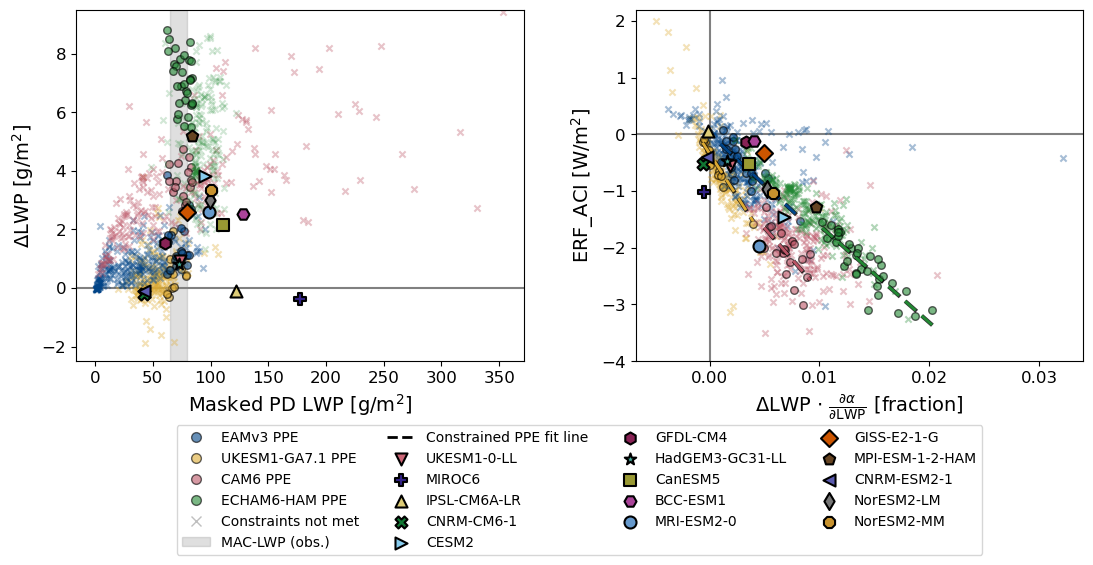

In [14]:
plot_comb_fig(ppe_dict, obs_range=pd_LWP_mac, save=True, figsize=(13, 7), alpha_ppe=0.6,
             extra="_Ndpipd")


In [17]:
def plot_PD_vs_delta_LWP_log(ppe_dict, xlim=None, ylim=None, wcrp_range=None, obs_range=None, is_log=False, 
                            figsize=(13, 6), fsize=14, tsize=16, labsize=12, 
                            alpha_ppe=0.5, s_ppe=20, s_cmip6=75, lw_wcrp=2, col_wcrp="#66CCEE",
                            alpha_wcrp=0.075, capsize=7, error_width=2.5,  save=False, extra="",
                            cmip6_colors=None, cmip6_markers=None, cmip6_plot_order=None,
                            show_fit_lines=False, mpe_range=None, show_bars=False, ppe_bins=None):
    """ Plot PD LWP vs delta LWP
    """
    if cmip6_colors is None:
        cmip6_colors = cmip6_colors_new # see above
    if cmip6_markers is None:
        cmip6_markers = ['v', 'P', '^', 'X', '>', 'h', '*', 's', 'H',
                         'o', 'D', 'p', '<', 'd', '8']
    if cmip6_plot_order is None:
        cmip6_plot_order = ["UKESM1-0-LL", "MIROC6", "IPSL-CM6A-LR", "CNRM-CM6-1", 
                            "CESM2", "GFDL-CM4", "HadGEM3-GC31-LL", "CanESM5", "BCC-ESM1",
                            "MRI-ESM2-0", "GISS-E2-1-G", "MPI-ESM-1-2-HAM", "CNRM-ESM2-1", 
                            "NorESM2-LM", "NorESM2-MM"]

    # hardcode PPE plot colors
    col_dict = {"GA7.1": "#DDAA33", "E3SMv3": "#004488", "CAM6": "#BB5566", "ECHAM6-HAM": "#228833"} # from tol-colors "high contrast", plus green
    est_col = "#997700" # for the multi-PPE best estimate

    # plot limits
    if xlim is None:
        xlim = (-0.2, 8)
    if ylim is None:
        ylim = (-0.075, 0.275)
            
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[5, 1])
    # plt.subplots_adjust(wspace=0.2)
    
    # plotting axis
    ax = plt.subplot(gs[0, 0])

    # axis to show the WCRP range
    if show_bars:
        ax_rng = plt.subplot(gs[0, 0])
        ax_rng.axis("off")

    # axis for the legend
    ax_leg = plt.subplot(gs[0, -1])
    ax_leg.axis("off")
    
    
    # --- set up axes & zero line ---
    ax.axhline(0, color="gray", linestyle="-")
    ax.set_ylabel(r"$\Delta$$\ln$LWP [$\ln$(g/m$^2$)]", fontsize=fsize)
    ax.set_xlabel(r"Masked PD $\ln$LWP [$\ln$(g/m$^2$)]", fontsize=fsize)
    ax.tick_params(axis="both", labelsize=labsize)
    ax.set_ylim(ylim)
    # ax.set_xlim(xlim)


    # --- obs ranges ---
    if obs_range is not None:
        ax.axvspan(obs_range[0], obs_range[1], color="gray", alpha=0.25, label="MAC-LWP (obs)",
                  zorder=0)
    
    # --- scatter PPE output  ---
    x = np.linspace(1, 5, 40) 
    
    # PPEs & CMIP6
    for ppe in list(ppe_dict.keys()):
        if ppe == "CMIP6":
            for i, model in enumerate(cmip6_plot_order):
                ax.scatter(ppe_dict["CMIP6"]["LWP"][model], ppe_dict["CMIP6"]["dLWP"][model], s=s_cmip6, label=model, alpha=1,
                           color=cmip6_colors[i], marker=cmip6_markers[i], edgecolor="k", linewidth=1.5, zorder=100)
        else:
            for ensn in ppe_dict[ppe]["LWP"].member:
                if ensn not in ppe_dict[ppe]["good_ensn"]:
                    marker = "x"
                    edgecolor = None
                    lw = None
                    if ppe == "ECHAM6-HAM": # smaller alpha for this one bc they're on top of each other
                        alph = 0.2
                    else:
                        alph = 0.35
                    s = s_ppe
                    ax.scatter(ppe_dict[ppe]["LWP"].sel(member=ensn), ppe_dict[ppe]["dLWP"].sel(member=ensn), alpha=alph,
                               s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                              edgecolor=edgecolor, linewidth=lw)

            for ensn in ppe_dict[ppe]["good_ensn"]:
                marker = "o"
                edgecolor="k"
                lw = 1
                alph = alpha_ppe
                s = s_ppe + 10
                ax.scatter(ppe_dict[ppe]["LWP"].sel(member=ensn), ppe_dict[ppe]["dLWP"].sel(member=ensn), alpha=alph,
                           s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                          edgecolor=edgecolor, linewidth=lw)


    # --- legend ---
    # CMIP6 
    handles, labels = ax.get_legend_handles_labels()

    # PPEs (constrained)
    for ppe in ["E3SMv3", "GA7.1", "CAM6", "ECHAM6-HAM"][::-1]:
        handles.insert(0, mlines.Line2D([], [], color=col_dict[ppe], markersize=7, linestyle="", markeredgecolor="k", 
                                       markeredgewidth=1, alpha=alpha_ppe, marker="o"))
        if ppe == "E3SMv3":
            lab = "EAMv3 PPE"
        elif ppe == "GA7.1":
            lab = "UKESM1-GA7.1 PPE"
        else:
            lab = f"{ppe} PPE"
        labels.insert(0, lab)

    # PPEs (do not meet constraints)
    handles.insert(4, mlines.Line2D([], [], color="gray", markersize=7, linestyle="", alpha=0.5, marker="x"))
    # labels.insert(4, r"PD LWP, $\Delta$Nd, or $\partial\alpha$/$\partial\text{LWP}$"+"\nconstraints not met")
    labels.insert(4, "Constraints not met")
       
    ax_leg.legend(handles, labels, loc="center", fontsize=labsize-2)

    # --- save ---
    if save:
        figname = f"FigS2_deltalnLWP_vs_PDlnLWP{extra}.png"
        plt.savefig(save_dir + figname, dpi=300, bbox_inches="tight")
    
    plt.show()


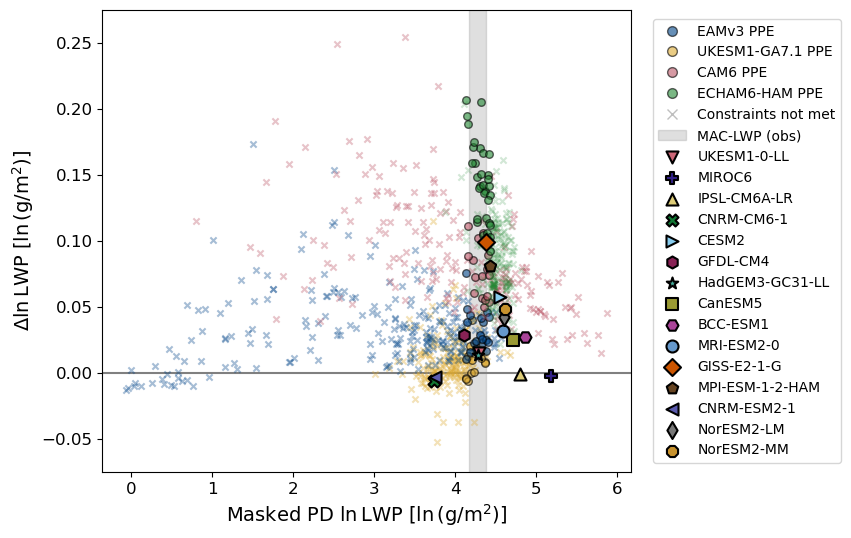

In [18]:
plot_PD_vs_delta_LWP_log(ppe_dict_log, obs_range=pd_lnLWP_mac, save=True, figsize=(9, 6), alpha_ppe=0.6,
                        extra="_Ndpipd")


In [16]:
def plot_ERFaci_vs_dLWP(ppe_dict, xlim=None, ylim=None, wcrp_range=None, obs_range=None, is_log=False, 
                            figsize=(13, 6), fsize=14, tsize=16, labsize=12, extra="", 
                            alpha_ppe=0.5, s_ppe=20, s_cmip6=75, lw_wcrp=2, col_wcrp="#66CCEE",
                            alpha_wcrp=0.075, capsize=7, error_width=2.5,  save=False,
                            cmip6_colors=None, cmip6_markers=None, cmip6_plot_order=None,
                            show_fit_lines=False, mpe_range=None, show_bars=False, ppe_bins=None):
    """ Plot ERFaci vs. dLWP (no scaling)
    """
    if cmip6_colors is None:
        cmip6_colors = cmip6_colors_new # see above
    if cmip6_markers is None:
        cmip6_markers = ['v', 'P', '^', 'X', '>', 'h', '*', 's', 'H',
                         'o', 'D', 'p', '<', 'd', '8']
    if cmip6_plot_order is None:
        cmip6_plot_order = ["UKESM1-0-LL", "MIROC6", "IPSL-CM6A-LR", "CNRM-CM6-1", 
                            "CESM2", "GFDL-CM4", "HadGEM3-GC31-LL", "CanESM5", "BCC-ESM1",
                            "MRI-ESM2-0", "GISS-E2-1-G", "MPI-ESM-1-2-HAM", "CNRM-ESM2-1", 
                            "NorESM2-LM", "NorESM2-MM"]

    # hardcode PPE plot colors
    col_dict = {"GA7.1": "#DDAA33", "E3SMv3": "#004488", "CAM6": "#BB5566", "ECHAM6-HAM": "#228833"} # from tol-colors "high contrast", plus green
    est_col = "#997700" # for the multi-PPE best estimate

    # plot limits
    if xlim is None:
        xlim = (-2.5, 9.5)
    if ylim is None:
        ylim = (-4, 2.2)
            
    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 2, width_ratios=[5, 1])
    # plt.subplots_adjust(wspace=0.2)
    
    # plotting axis
    ax = plt.subplot(gs[0, 0])

    # axis to show the WCRP range
    if show_bars:
        ax_rng = plt.subplot(gs[0, 0])
        ax_rng.axis("off")

    # axis for the legend
    ax_leg = plt.subplot(gs[0, -1])
    ax_leg.axis("off")
    
    
    # --- set up axes & zero line ---
    ax.axhline(0, color="gray", linestyle="-")
    ax.axvline(0, color="gray", linestyle="-")
    ax.set_xlabel(r"$\Delta$LWP [g/m$^2$]", fontsize=fsize)
    ax.set_ylabel("ERF_ACI [W/m$^2$]", fontsize=fsize)
    ax.tick_params(axis="both", labelsize=labsize)
    ax.set_ylim(ylim)
    # ax.set_xlim(xlim)


    # --- obs ranges ---
    if obs_range is not None:
        ax.axvspan(obs_range[0], obs_range[1], color="gray", alpha=0.25, label="MAC-LWP (obs)",
                  zorder=0)
    
    # --- scatter PPE output  ---
    x = np.linspace(1, 5, 40) 
    
    # PPEs & CMIP6
    for ppe in list(ppe_dict.keys()):
        if ppe == "CMIP6":
            for i, model in enumerate(cmip6_plot_order):
                ax.scatter(ppe_dict["CMIP6"]["dLWP"][model], ppe_dict["CMIP6"]["ERFaci"][model], s=s_cmip6, label=model, alpha=1,
                           color=cmip6_colors[i], marker=cmip6_markers[i], edgecolor="k", linewidth=1.5, zorder=100)
        else:
            for ensn in ppe_dict[ppe]["dLWP"].member:
                if ensn not in ppe_dict[ppe]["good_ensn"]:
                    marker = "x"
                    edgecolor = None
                    lw = None
                    if ppe == "ECHAM6-HAM": # smaller alpha for this one bc they're on top of each other
                        alph = 0.2
                    else:
                        alph = 0.35
                    s = s_ppe
                    ax.scatter(ppe_dict[ppe]["dLWP"].sel(member=ensn), ppe_dict[ppe]["ERFaci"].sel(member=ensn), alpha=alph,
                               s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                              edgecolor=edgecolor, linewidth=lw)
                    
            for ensn in ppe_dict[ppe]["good_ensn"]:
                marker = "o"
                edgecolor="k"
                lw = 1
                alph = alpha_ppe
                s = s_ppe + 10
                ax.scatter(ppe_dict[ppe]["dLWP"].sel(member=ensn), ppe_dict[ppe]["ERFaci"].sel(member=ensn), alpha=alph,
                       s=s, zorder=2, marker=marker, color=col_dict[ppe], # label=f"{ppe} PPE",
                      edgecolor=edgecolor, linewidth=lw)
                
            # add fit lines
            good = ppe_dict[ppe]["good_ensn"]
            xspan = np.linspace(ppe_dict[ppe]["dLWP"].sel(member=good).min(), ppe_dict[ppe]["dLWP"].sel(member=good).max(), 40)
            pi_fit = mpc.linear(xspan, ppe_dict[ppe]["noscale_coeffs"]) 
            # "outer" line
            ax.plot(xspan, pi_fit, linestyle="--", color="k", linewidth=3, zorder=99, alpha=0.8)
            # "inner" line - idk why this exact dash specification works, but it does
            ax.plot(xspan, pi_fit, linestyle="--", color=col_dict[ppe], linewidth=2, zorder=99, dashes=[5, 2.95])




    # --- legend ---
    # CMIP6 
    handles, labels = ax.get_legend_handles_labels()

    # PPEs (constrained)
    for ppe in ["E3SMv3", "GA7.1", "CAM6", "ECHAM6-HAM"][::-1]:
        handles.insert(0, mlines.Line2D([], [], color=col_dict[ppe], markersize=7, linestyle="", markeredgecolor="k", 
                                       markeredgewidth=1, alpha=alpha_ppe, marker="o"))
        if ppe == "E3SMv3":
            lab = "EAMv3 PPE"
        elif ppe == "GA7.1":
            lab = "UKESM1-GA7.1 PPE"
        else:
            lab = f"{ppe} PPE"
        labels.insert(0, lab)

    # PPEs (do not meet constraints)
    handles.insert(4, mlines.Line2D([], [], color="gray", markersize=7, linestyle="", alpha=0.5, marker="x"))
    # labels.insert(4, r"PD LWP, $\Delta$Nd, or $\partial\alpha$/$\partial\text{LWP}$"+"\nconstraints not met")
    labels.insert(4, "Constraints not met")

    # fit line
    handles.insert(5, mlines.Line2D([], [], color="k", linewidth=2, linestyle="--"))
    labels.insert(5, "Constrained PPE fit line")
    
    ax_leg.legend(handles, labels, loc="center", fontsize=labsize-2)

    
    # --- save ---
    if save:
        figname = f"FigS3_ERFaci_vs_dLWP{extra}.png"
        plt.savefig(save_dir + figname, dpi=300, bbox_inches="tight")
    
    plt.show()


In [ ]:
plot_ERFaci_vs_dLWP(ppe_dict, save=True, figsize=(9, 6), alpha_ppe=0.6, extra="_Ndpipd")
